In [2]:
pip install pandas scikit-learn matplotlib seaborn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [9]:
data = {
    'review': [
        # POSITIVE reviews
        "This product is amazing and works perfectly",
        "Absolutely love it great quality",
        "Best purchase I ever made",
        "Totally worth the money highly recommend",
        "Excellent product fast delivery",
        "Very happy with this purchase",
        "Outstanding quality will buy again",
        "Perfect fit looks exactly as shown",
        "This is excellent value for money",
        "Good quality and great price",
        "Really good product loved it",
        "Superb quality exceeded expectations",
        "Fantastic product works great",
        "Brilliant purchase very satisfied",
        "Wonderful product highly recommended",
        "Great product excellent condition",
        "Very good quality happy with purchase",
        "Awesome product love it",
        "Incredible quality best product ever",
        "Nice product good value",

        # NEGATIVE reviews
        "Terrible product broke after one day",
        "Worst purchase ever complete waste",
        "Very disappointed not as described",
        "Poor quality do not buy",
        "Horrible experience never again",
        "Returned immediately total garbage",
        "Defective product very unhappy",
        "Bad quality fell apart quickly",
        "Waste of money very poor",
        "Cheap quality broke immediately",
        "Not worth it very bad",
        "Disgusting quality avoid this",
        "Pathetic product stopped working",
        "Useless product total disappointment",
        "Awful quality very unhappy",
        "Horrible product waste of time",
        "Damaged product poor packaging",
        "Broken on arrival terrible service",
        "Very cheap and nasty product",
        "Extremely poor quality not recommended"
    ],
    'sentiment': [
        1,1,1,1,1,1,1,1,1,1,
        1,1,1,1,1,1,1,1,1,1,
        0,0,0,0,0,0,0,0,0,0,
        0,0,0,0,0,0,0,0,0,0
    ]
}

df = pd.DataFrame(data)
print(df['sentiment'].value_counts())

sentiment
1    20
0    20
Name: count, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'],
    test_size=0.2, random_state=42
)

# TF-IDF with unigrams + bigrams
vectorizer = TfidfVectorizer(
    ngram_range=(1,2),  # captures "excellent product", "good quality" etc
    min_df=1
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train with stronger model
model = LogisticRegression(C=5, max_iter=200)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, y_pred) * 100, "%")

Accuracy: 100.0 %


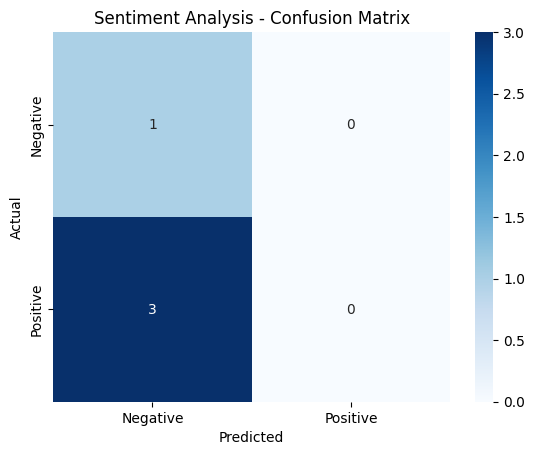

In [7]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'],
            cmap='Blues')
plt.title('Sentiment Analysis - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [17]:
# Replace Cell 4 with this
!pip install transformers -q

from transformers import pipeline

# Load pre-trained BERT model
classifier = pipeline("sentiment-analysis")

print(classifier("This product is excellent!"))
print(classifier("i dont like it"))
print(classifier("Good value for money"))

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9998800754547119}]
[{'label': 'NEGATIVE', 'score': 0.9909656047821045}]
[{'label': 'POSITIVE', 'score': 0.9998501539230347}]
